# (Short) EDA of the datasets

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper")

langcols = {
    'English': '#0474BA',
    'Greek': '#00A7E1',
    'Spanish': '#FFA630'
}

noise_order = ['randomly_swapped_words', 'consecutively_swapped_words', 'deleted_words', 'removed_sentence', 'inserted_sentence', 'repeated_sentence']

## Merged datasets

In [ ]:
df = pd.read_parquet('../results/eda/text_stats.parquet')
reports = df[df['doc_type'] == 'annual_reports']
golds = df[df['doc_type'] == 'gold_summaries']
cands = df[df['doc_type'] == 'candidate_summaries_trunc']
df

,doc_id,dataset,version,noise_variant,doc_type,language,text,spacy_token_count,spacy_sent_count,bert_token_count
0,10063,training,None,None,annual_reports,English,MELROSE PLC ANNUAL REPORT 2006\nMelrose PLC\n...,NaN,NaN,53655.0
1,10068,training,None,None,annual_reports,English,21012-04 Proof 6 26/3/2012 21012-04 Proo...,NaN,NaN,98709.0
2,1007,training,None,None,annual_reports,English,APG01 | AR13 | 28/03/2014 | COVER ART APG01 |...,NaN,NaN,80971.0
3,10073,training,None,None,annual_reports,English,Mentmore plc\nPark House\n14 Pepys Road\nLond...,NaN,NaN,31488.0
4,1008,training,None,None,annual_reports,English,2014 \nAnnual Report & Accounts\nANGLO PACIFI...,NaN,NaN,80542.0
...,...,...,...,...,...,...,...,...,...,...
38686,0178,training,GS1,None,gold_summaries,Spanish,Este año 2016 hemos celebrado un aniversario e...,1412.0,42.0,1808.0
38687,0179,training,GS1,None,gold_summaries,Spanish,El nivel de participación de los extranjeros t...,1043.0,36.0,1307.0
38688,0180,training,GS1,None,gold_summaries,Spanish,Un año más tengo el placer de dirigirme a uste...,594.0,14.0,757.0
38689,0181,training,GS1,None,gold_summaries,Spanish,NH Hotel Group ha dado grandes pasos desde que...,816.0,18.0,1060.0


In [24]:
print('Document counts by language and type:')

pd.crosstab(df['doc_type'], df['language'])

Document counts by language and type:


language,English,Greek,Spanish
doc_type,,,
annual_reports,817,212,182
candidate_summaries_trunc,24480,6330,5460
gold_summaries,816,212,182


## Annual reports and gold summaries

In [25]:
reports['bert_token_count'].describe().round(2)

count      1211.00
mean      72477.88
std       56421.85
min         451.00
25%       37828.50
50%       61077.00
75%       92003.00
max      808708.00
Name: bert_token_count, dtype: float64

Text(0, 0.5, 'Word Tokens')

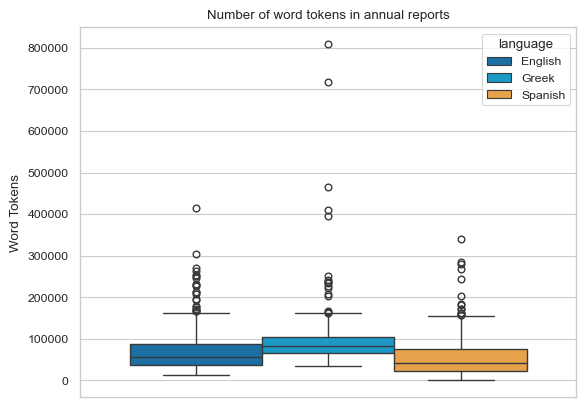

In [108]:
sns.boxplot(data=reports, y='bert_token_count', hue='language', palette=langcols)
plt.title('Number of word tokens in annual reports')
plt.ylabel('Word Tokens')

Text(0, 0.5, 'Words')

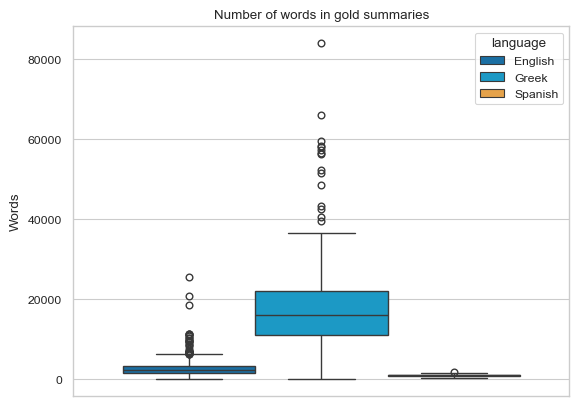

In [106]:
sns.boxplot(data=golds, y='spacy_token_count', hue='language', palette=langcols)
plt.title('Number of words in gold summaries')
plt.ylabel('Words')

In [88]:
golds.groupby('language')['spacy_token_count'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
English,816.0,2732.62,2097.88,51.0,1488.75,2273.0,3421.25,25459.0
Greek,212.0,19093.30,12525.74,0.0,11035.50,16006.5,22045.00,84078.0
Spanish,182.0,920.57,245.16,249.0,722.50,994.0,1089.50,1711.0


Text(0, 0.5, 'Sentences')

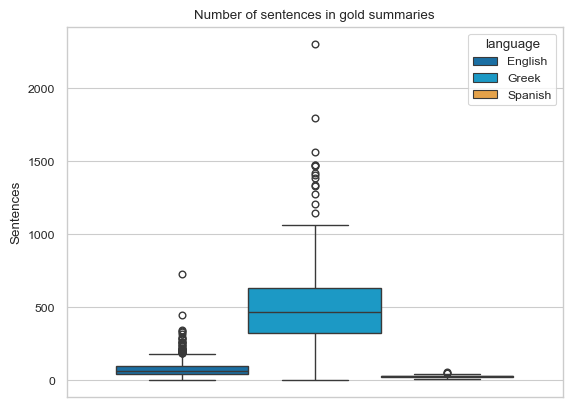

In [103]:
sns.boxplot(data=golds, y='spacy_sent_count', hue='language', palette=langcols)
plt.title('Number of sentences in gold summaries')
plt.ylabel('Sentences')

C:\Users\Stefania\AppData\Local\Temp\ipykernel_51800\1256240042.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=golds[golds['language'] == 'English'], x='spacy_sent_count', palette=langcols)


Text(0.5, 0, 'Sentences')

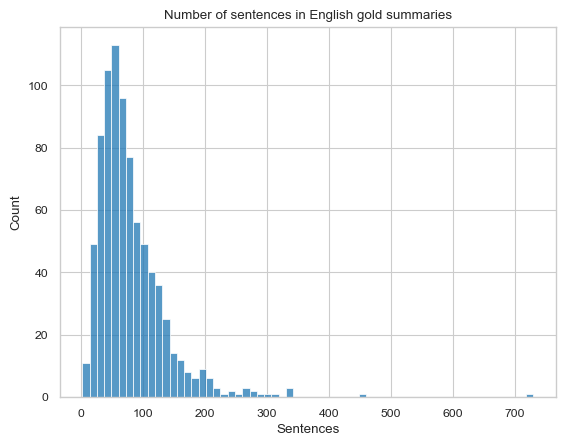

In [102]:
sns.histplot(data=golds[golds['language'] == 'English'], x='spacy_sent_count', palette=langcols)
plt.title('Number of sentences in English gold summaries')
plt.xlabel('Sentences')

Text(0.5, 0, 'Sentences')

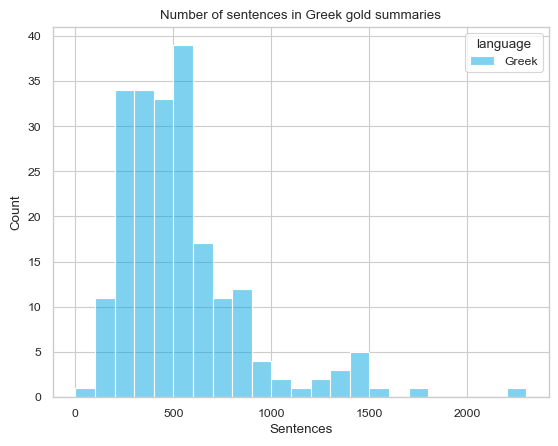

In [101]:
sns.histplot(data=golds[golds['language'] == 'Greek'], x='spacy_sent_count', hue='language', palette=langcols)
plt.title('Number of sentences in Greek gold summaries')
plt.xlabel('Sentences')

Text(0.5, 0, 'Sentences')

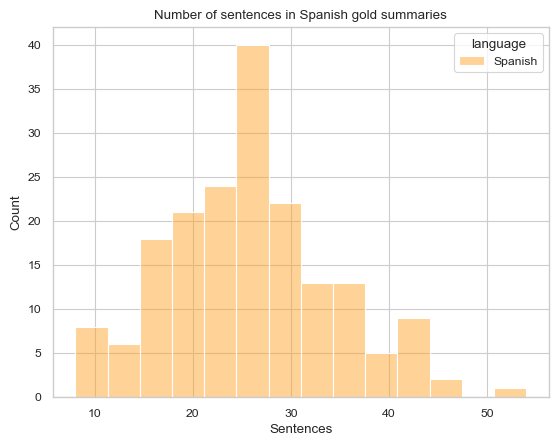

In [100]:
sns.histplot(data=golds[golds['language'] == 'Spanish'], x='spacy_sent_count', hue='language', palette=langcols)
plt.title('Number of sentences in Spanish gold summaries')
plt.xlabel('Sentences')

Text(0.5, 1.0, 'Number of word tokens in gold summaries')

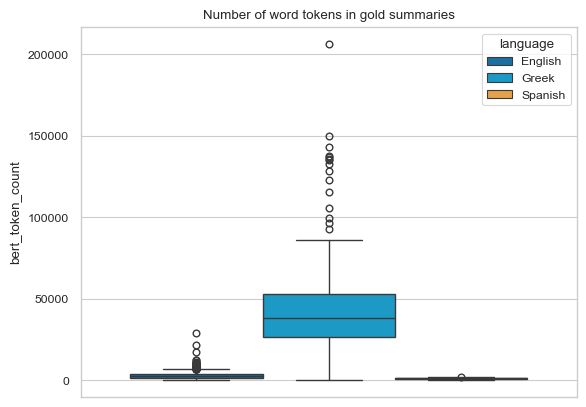

In [97]:
sns.boxplot(data=golds, y='bert_token_count', hue='language', palette=langcols)
plt.title('Number of word tokens in gold summaries')

## Generated summaries

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'randomly_swapped_words'),
  Text(1, 0, 'consecutively_swapped_words'),
  Text(2, 0, 'deleted_words'),
  Text(3, 0, 'removed_sentence'),
  Text(4, 0, 'inserted_sentence'),
  Text(5, 0, 'repeated_sentence')])

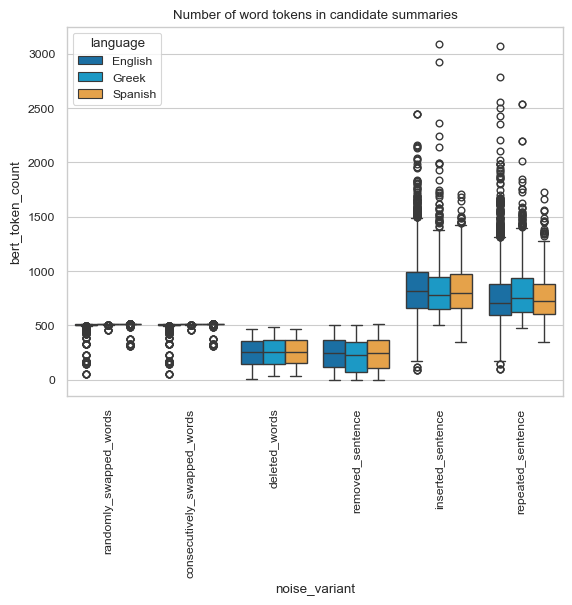

In [98]:
sns.boxplot(data=cands, y='bert_token_count', x='noise_variant', hue='language', palette=langcols, order=noise_order)
plt.title('Number of word tokens in candidate summaries')
plt.xticks(rotation=90)